<a href="https://colab.research.google.com/github/Ishini01/garment_defect_system/blob/main/Brokenstitches.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Broken Stitch Detection Using a Weighted Ensemble Model

This notebook implements the final **broken stitch detection component** of the garment defect detection system.

Three independently trained deep learning models are combined using **weighted soft voting**:

- MobileNetV2
- EfficientNetB0
- Vision Transformer (ViT)

The ensemble combines the predicted probability of the **Broken Stitches** class from each model using optimized validation-based weights.

### Final Ensemble Weights

- EfficientNetB0: **0.25**
- MobileNetV2: **0.40**
- Vision Transformer: **0.35**

The final ensemble is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix
- Model performance comparison

## 1. Mount Google Drive

Google Drive is mounted to access the trained model files and the broken-stitch image dataset stored in the project directory.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## 2. Import Required Libraries

The required Python libraries are imported for deep learning model loading, image preprocessing, numerical operations, and ensemble prediction.

MobileNetV2 uses its architecture-specific `preprocess_input()` function, while EfficientNetB0 and ViT receive image arrays using the preprocessing configuration used during their original training.

In [2]:
import os
import numpy as np
import tensorflow as tf
import keras
import keras_hub

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

## 3. Define Trained Model Paths

The paths of the three previously trained `.keras` model files are defined below.

Each model was trained independently for binary classification between:

- **Normal Stitches**
- **Broken Stitches**

In [3]:
MOBILENET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/mobileNet_Model.keras"
EFFICIENTNET_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/EfficientNet.keras"
VIT_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/ViT_Model.keras"

## 4. Load the Individual Classification Models

The trained MobileNetV2, EfficientNetB0, and Vision Transformer models are loaded from Google Drive.

These models remain independent classifiers. Their outputs are later combined using decision-level weighted soft voting.

In [4]:
mobilenet_model = keras.models.load_model(MOBILENET_PATH)
efficientnet_model = keras.models.load_model(EFFICIENTNET_PATH)
vit_model = keras.models.load_model(VIT_PATH)

print("All models loaded successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


All models loaded successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## 5. Image Preprocessing

All input images are resized to **224 × 224 pixels**, which matches the expected input dimensions of the three classifiers.

Since the models were trained using different preprocessing pipelines, model-specific preprocessing is applied before inference.

- MobileNetV2 uses `mobilenet_v2.preprocess_input()`.
- EfficientNetB0 receives the raw resized image array according to its training pipeline.
- ViT receives the raw resized image array according to its preset preprocessing pipeline.

In [6]:
IMG_SIZE = (224, 224)

def prepare_image(img_path):

    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    mobile_img = mobilenet_preprocess(
        img_array.copy()
    )

    efficient_img = img_array.copy()

    vit_img = img_array.copy()

    return mobile_img, efficient_img, vit_img

## 6. Obtain Probabilities from the Three Models

For each input image, the three classifiers generate a prediction.

To combine them correctly, all model outputs are converted into the same semantic quantity:

> **Probability that the image contains Broken Stitches**

For MobileNetV2 and EfficientNetB0, the sigmoid output directly represents the broken-stitch probability.

For ViT, the softmax probability corresponding to the broken-stitch class is extracted.

In [7]:
def predict_probabilities(img_path):

    mobile_img, efficient_img, vit_img = prepare_image(img_path)

    # MobileNet
    mobile_prob = float(
        mobilenet_model.predict(
            mobile_img,
            verbose=0
        )[0][0]
    )

    # EfficientNet
    efficient_prob = float(
        efficientnet_model.predict(
            efficient_img,
            verbose=0
        )[0][0]
    )

    # ViT
    vit_output = vit_model.predict(
        vit_img,
        verbose=0
    )

    vit_probs = tf.nn.softmax(
        vit_output,
        axis=1
    ).numpy()

    # IMPORTANT:
    # ViT class 0 = Broken
    # ViT class 1 = Normal
    vit_prob = float(vit_probs[0][0])

    return {
        "MobileNet": mobile_prob,
        "EfficientNet": efficient_prob,
        "ViT": vit_prob
    }

In [11]:
IMG_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test/broken stitches/BS (1015).jpg"

probs = predict_probabilities(IMG_PATH)

majority_label, votes = majority_vote(probs)

weighted_label, weighted_prob = weighted_average(probs)

print("Model probabilities:")
print(probs)

print("\nMajority voting:")
print(votes)
print("Final:", majority_label)

print("\nWeighted average:")
print("Broken-stitch probability:", weighted_prob)
print("Final:", weighted_label)

Model probabilities:
{'MobileNet': 0.2662750780582428, 'EfficientNet': 0.8239187598228455, 'ViT': 0.35708215832710266}

Majority voting:
{'MobileNet': 0, 'EfficientNet': 1, 'ViT': 0}
Final: Normal Stitches

Weighted average:
Broken-stitch probability: 0.5165746748447418
Final: broken stitches


## 7. Validation Dataset for Ensemble Weight Optimization

A common validation dataset is used to determine the contribution of each base classifier to the final ensemble.

The validation dataset contains the two classes:

- `Normal Stitches`
- `broken stitches`

The class encoding used throughout the ensemble evaluation is:

- **0 = Normal Stitches**
- **1 = Broken Stitches**

In [12]:
VALIDATION_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/validation"

CLASS_NAMES = [
    "Normal Stitches",
    "broken stitches"
]

IMG_SIZE = (224, 224)

### 7.1 Load Validation Images

All validation images are loaded and resized to **224 × 224 pixels**.

The true class labels are stored in `y_true`, while the image data are retained for batch inference.

Batch processing is used instead of predicting images individually because it significantly reduces inference time.

In [13]:
def prepare_image(img_path):

    img = image.load_img(
        img_path,
        target_size=IMG_SIZE
    )

    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    mobile_img = mobilenet_preprocess(
        img_array.copy()
    )

    efficient_img = img_array.copy()

    vit_img = img_array.copy()

    return mobile_img, efficient_img, vit_img

### 7.2 Prepare Model-Specific Validation Inputs

Separate input arrays are created for each classifier.

MobileNetV2 requires architecture-specific preprocessing, whereas the EfficientNetB0 and ViT inputs follow their original training preprocessing configurations.

In [14]:
def predict_three_models(img_path):

    mobile_img, efficient_img, vit_img = prepare_image(img_path)

    # MobileNet
    mobile_prob = float(
        mobilenet_model.predict(
            mobile_img,
            verbose=0
        )[0][0]
    )

    # EfficientNet
    efficient_prob = float(
        efficientnet_model.predict(
            efficient_img,
            verbose=0
        )[0][0]
    )

    # ViT
    vit_output = vit_model.predict(
        vit_img,
        verbose=0
    )

    vit_probs = tf.nn.softmax(
        vit_output,
        axis=1
    ).numpy()

    # ViT:
    # class 0 = Broken
    # class 1 = Normal
    vit_prob = float(vit_probs[0][0])

    return mobile_prob, efficient_prob, vit_prob

In [15]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

IMG_SIZE = (224, 224)

all_raw_images = []
y_true = []

for class_index, class_name in enumerate(CLASS_NAMES):

    class_folder = os.path.join(
        VALIDATION_PATH,
        class_name
    )

    for file_name in os.listdir(class_folder):

        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        img_path = os.path.join(
            class_folder,
            file_name
        )

        img = image.load_img(
            img_path,
            target_size=IMG_SIZE
        )

        img_array = image.img_to_array(img)

        all_raw_images.append(img_array)
        y_true.append(class_index)


all_raw_images = np.array(all_raw_images)
y_true = np.array(y_true)

print("Images loaded:", len(all_raw_images))

Images loaded: 361


### 7.3 Generate Validation Predictions

Each trained model performs inference on the complete validation dataset.

The resulting arrays contain the estimated probability of the **Broken Stitches** class for every validation image.

In [16]:
mobile_images = mobilenet_preprocess(
    all_raw_images.copy()
)

efficient_images = all_raw_images.copy()

vit_images = all_raw_images.copy()

In [17]:
mobile_probs = mobilenet_model.predict(
    mobile_images,
    batch_size=32,
    verbose=1
).ravel()

12/12 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


In [18]:
efficient_probs = efficientnet_model.predict(
    efficient_images,
    batch_size=32,
    verbose=1
).ravel()

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 869ms/step


#### ViT Class Probability Conversion

The ViT model produces two output logits. Softmax is applied to convert them into class probabilities.

The probability corresponding to the **Broken Stitches** class is selected so that all three models provide the same output meaning before ensemble fusion.

In [19]:
vit_logits = vit_model.predict(
    vit_images,
    batch_size=32,
    verbose=1
)

vit_softmax = tf.nn.softmax(
    vit_logits,
    axis=1
).numpy()

# Column 1 = probability of broken stitches
vit_probs_all = vit_softmax[:, 1]

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 651ms/step


### 7.4 Verify Validation Dataset Distribution

The number of samples from each class is verified before weight optimization to ensure that the labels and prediction arrays are aligned correctly.

In [20]:
y_true = np.array(y_true)

mobile_probs = np.array(mobile_probs)
efficient_probs = np.array(efficient_probs)
vit_probs_all = np.array(vit_probs_all)

print("Validation images:", len(y_true))

print("Normal images:", np.sum(y_true == 0))
print("Broken images:", np.sum(y_true == 1))

Validation images: 361
Normal images: 209
Broken images: 152


## 8. Ensemble Weight Optimization

The final classifier uses **weighted soft voting**.

The ensemble probability is calculated as:

\[
P_{ensemble} =
w_E P_E +
w_M P_M +
w_V P_V
\]

where:

- \(P_E\) = EfficientNetB0 probability of Broken Stitches
- \(P_M\) = MobileNetV2 probability of Broken Stitches
- \(P_V\) = ViT probability of Broken Stitches
- \(w_E + w_M + w_V = 1\)

Different weight combinations are evaluated using the validation dataset.

The combination that produces the highest **F1-score for the Broken Stitches class** is selected as the final ensemble configuration.

In [21]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

best_f1 = -1
best_weights = None
best_metrics = None

step = 0.05

for w_eff in np.arange(0, 1.01, step):

    for w_mobile in np.arange(0, 1.01 - w_eff, step):

        w_vit = 1.0 - w_eff - w_mobile

        if w_vit < 0:
            continue

        # Weighted ensemble probability
        ensemble_prob = (
            w_eff * efficient_probs
            + w_mobile * mobile_probs
            + w_vit * vit_probs_all
        )

        # Final prediction
        y_pred = (ensemble_prob >= 0.5).astype(int)

        accuracy = accuracy_score(y_true, y_pred)

        precision = precision_score(
            y_true,
            y_pred,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            y_pred,
            zero_division=0
        )

        if f1 > best_f1:

            best_f1 = f1

            best_weights = (
                w_eff,
                w_mobile,
                w_vit
            )

            best_metrics = (
                accuracy,
                precision,
                recall,
                f1
            )

### 8.1 Selected Ensemble Weights

The validation-based optimization identified the following optimal weights:

- EfficientNetB0: **0.25**
- MobileNetV2: **0.40**
- Vision Transformer: **0.35**

These weights are frozen before evaluating the final ensemble on the independent test dataset.

In [22]:
print("BEST ENSEMBLE WEIGHTS")
print("----------------------")

print(f"EfficientNet: {best_weights[0]:.2f}")
print(f"MobileNet:    {best_weights[1]:.2f}")
print(f"ViT:          {best_weights[2]:.2f}")

print("\nVALIDATION PERFORMANCE")
print("----------------------")

print(f"Accuracy : {best_metrics[0]:.4f}")
print(f"Precision: {best_metrics[1]:.4f}")
print(f"Recall   : {best_metrics[2]:.4f}")
print(f"F1 Score : {best_metrics[3]:.4f}")

BEST ENSEMBLE WEIGHTS
----------------------
EfficientNet: 0.25
MobileNet:    0.40
ViT:          0.35

VALIDATION PERFORMANCE
----------------------
Accuracy : 0.9945
Precision: 0.9870
Recall   : 1.0000
F1 Score : 0.9935


## 9. Final Evaluation on the Test Dataset

After selecting and freezing the ensemble weights, the final weighted ensemble is evaluated on the independent test dataset.

The test set is not used for weight optimization. It is used only to measure the final generalization performance of the ensemble.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(name, probs):

    preds = (probs >= 0.5).astype(int)

    print(f"\n{name}")
    print("-" * 30)

    print(
        "Accuracy :",
        round(accuracy_score(y_true, preds), 4)
    )

    print(
        "Precision:",
        round(
            precision_score(
                y_true,
                preds,
                zero_division=0
            ),
            4
        )
    )

    print(
        "Recall   :",
        round(
            recall_score(
                y_true,
                preds,
                zero_division=0
            ),
            4
        )
    )

    print(
        "F1 Score :",
        round(
            f1_score(
                y_true,
                preds,
                zero_division=0
            ),
            4
        )
    )


evaluate_model(
    "MobileNet",
    mobile_probs
)

evaluate_model(
    "EfficientNet",
    efficient_probs
)

evaluate_model(
    "ViT",
    vit_probs_all
)


MobileNet
------------------------------
Accuracy : 0.9889
Precision: 0.9868
Recall   : 0.9868
F1 Score : 0.9868

EfficientNet
------------------------------
Accuracy : 0.964
Precision: 0.9728
Recall   : 0.9408
F1 Score : 0.9565

ViT
------------------------------
Accuracy : 0.9003
Precision: 0.9085
Recall   : 0.8487
F1 Score : 0.8776


In [24]:
print("ViT probability statistics")
print("--------------------------")

print("Min :", vit_probs_all.min())
print("Max :", vit_probs_all.max())
print("Mean:", vit_probs_all.mean())

print(
    "Predicted broken:",
    np.sum(vit_probs_all >= 0.5)
)

print(
    "Predicted normal:",
    np.sum(vit_probs_all < 0.5)
)

ViT probability statistics
--------------------------
Min : 0.003058446
Max : 0.99655545
Mean: 0.43715733
Predicted broken: 142
Predicted normal: 219


### 9.1 Load Test Images

The test images are loaded, resized to **224 × 224 pixels**, and assigned their corresponding binary class labels.

The same class encoding is maintained:

- **0 = Normal Stitches**
- **1 = Broken Stitches**

In [25]:
TEST_PATH = "/content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test"

CLASS_NAMES = [
    "Normal Stitches",
    "broken stitches"
]

IMG_SIZE = (224, 224)

### 9.2 Prepare Test Inputs for Each Model

The test images are preprocessed separately according to the requirements of MobileNetV2, EfficientNetB0, and ViT.

In [26]:
import os
import numpy as np
from tensorflow.keras.preprocessing import image

test_raw_images = []
y_test = []

for class_index, class_name in enumerate(CLASS_NAMES):

    class_folder = os.path.join(
        TEST_PATH,
        class_name
    )

    print(f"Loading: {class_folder}")

    for file_name in os.listdir(class_folder):

        if not file_name.lower().endswith(
            (".jpg", ".jpeg", ".png")
        ):
            continue

        img_path = os.path.join(
            class_folder,
            file_name
        )

        img = image.load_img(
            img_path,
            target_size=IMG_SIZE
        )

        img_array = image.img_to_array(img)

        test_raw_images.append(img_array)
        y_test.append(class_index)


test_raw_images = np.array(test_raw_images)
y_test = np.array(y_test)

print("\nTest images:", len(y_test))
print("Normal:", np.sum(y_test == 0))
print("Broken:", np.sum(y_test == 1))
print("Image shape:", test_raw_images.shape)

Loading: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test/Normal Stitches
Loading: /content/drive/MyDrive/Dataset_GarmentDefectDetection/KaggleBrokenStitches/split_dataset/test/broken stitches

Test images: 364
Normal: 210
Broken: 154
Image shape: (364, 224, 224, 3)


### 9.3 Generate Test Predictions

Each classifier predicts the probability of broken stitches for every image in the independent test dataset.

The ViT output is converted using softmax so that its probability representation is consistent with the two CNN-based classifiers.

In [27]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

mobile_test_images = mobilenet_preprocess(
    test_raw_images.copy()
)

efficient_test_images = test_raw_images.copy()

vit_test_images = test_raw_images.copy()

In [28]:
mobile_test_probs = mobilenet_model.predict(
    mobile_test_images,
    batch_size=32,
    verbose=1
).ravel()

print("MobileNet predictions:", mobile_test_probs.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
MobileNet predictions: (364,)


In [29]:
efficient_test_probs = efficientnet_model.predict(
    efficient_test_images,
    batch_size=32,
    verbose=1
).ravel()

print("EfficientNet predictions:", efficient_test_probs.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
EfficientNet predictions: (364,)


In [30]:
import tensorflow as tf

vit_test_logits = vit_model.predict(
    vit_test_images,
    batch_size=32,
    verbose=1
)

vit_test_softmax = tf.nn.softmax(
    vit_test_logits,
    axis=1
).numpy()

# Corrected:
# column 1 = probability of Broken Stitch
vit_test_probs = vit_test_softmax[:, 1]

print("ViT predictions:", vit_test_probs.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 666ms/step
ViT predictions: (364,)


In [31]:
EFF_WEIGHT = 0.25
MOBILE_WEIGHT = 0.40
VIT_WEIGHT = 0.35

ensemble_test_probs = (
    EFF_WEIGHT * efficient_test_probs
    +
    MOBILE_WEIGHT * mobile_test_probs
    +
    VIT_WEIGHT * vit_test_probs
)

y_test_pred = (
    ensemble_test_probs >= 0.5
).astype(int)

## 10. Weighted Ensemble Prediction

The optimized weights obtained from validation are applied to the test-set probabilities:

\[
P_{ensemble} =
0.25P_{EfficientNet}
+
0.40P_{MobileNet}
+
0.35P_{ViT}
\]

A classification threshold of **0.50** is used.

- If \(P_{ensemble} \geq 0.50\), the image is classified as **Broken Stitches**.
- Otherwise, it is classified as **Normal Stitches**.

In [32]:
print("Final Ensemble Prediction Distribution")
print("--------------------------------------")

print(
    "Predicted Normal:",
    np.sum(y_test_pred == 0)
)

print(
    "Predicted Broken:",
    np.sum(y_test_pred == 1)
)

print("\nProbability range:")
print("Min :", ensemble_test_probs.min())
print("Max :", ensemble_test_probs.max())
print("Mean:", ensemble_test_probs.mean())

Final Ensemble Prediction Distribution
--------------------------------------
Predicted Normal: 211
Predicted Broken: 153

Probability range:
Min : 0.0042474405
Max : 0.9988604
Mean: 0.43461627


## 11. Final Ensemble Performance Metrics

The final ensemble is evaluated using standard binary classification metrics:

- **Accuracy** — overall proportion of correctly classified images.
- **Precision** — proportion of predicted broken-stitch images that are actually defective.
- **Recall** — proportion of actual broken-stitch images correctly detected.
- **F1-score** — harmonic mean of precision and recall.

For this defect detection task, recall is particularly important because a false negative represents a defective stitch that was not detected.

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

print("FINAL ENSEMBLE TEST RESULTS")
print("---------------------------")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

FINAL ENSEMBLE TEST RESULTS
---------------------------
Accuracy : 0.9808
Precision: 0.9804
Recall   : 0.9740
F1 Score : 0.9772


### 11.1 Classification Report

The classification report provides precision, recall, F1-score, and support separately for both the Normal Stitches and Broken Stitches classes.

In [34]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=[
            "Normal Stitches",
            "broken stitches"
        ],
        digits=4
    )
)


Classification Report

                 precision    recall  f1-score   support

Normal Stitches     0.9810    0.9857    0.9834       210
broken stitches     0.9804    0.9740    0.9772       154

       accuracy                         0.9808       364
      macro avg     0.9807    0.9799    0.9803       364
   weighted avg     0.9808    0.9808    0.9808       364



### 11.2 Confusion Matrix

The confusion matrix provides a detailed view of the ensemble predictions.

It shows:

- True Normal predicted as Normal
- True Normal predicted as Broken
- True Broken predicted as Normal
- True Broken predicted as Broken

This helps identify the number of false positives and false negatives produced by the final ensemble.

Confusion Matrix:
[[207   3]
 [  4 150]]


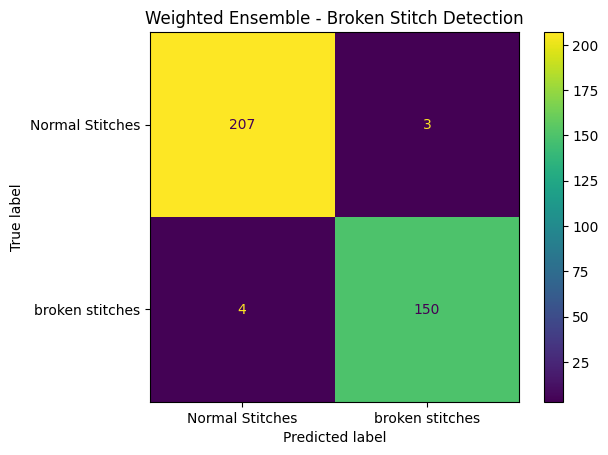

In [35]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(
    y_test,
    y_test_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal Stitches",
        "broken stitches"
    ]
)

disp.plot(
    values_format="d"
)

plt.title(
    "Weighted Ensemble - Broken Stitch Detection"
)

plt.show()

## 12. Comparison with Individual Models

The final weighted ensemble is compared against the three individual classifiers using the same test dataset.

This comparison determines whether combining the models improves generalization performance compared with using any single classifier.

In [36]:
def evaluate_test_model(name, probs):

    preds = (probs >= 0.5).astype(int)

    print(f"\n{name}")
    print("-" * 35)

    print(
        f"Accuracy : {accuracy_score(y_test, preds):.4f}"
    )

    print(
        f"Precision: {precision_score(y_test, preds, zero_division=0):.4f}"
    )

    print(
        f"Recall   : {recall_score(y_test, preds, zero_division=0):.4f}"
    )

    print(
        f"F1 Score : {f1_score(y_test, preds, zero_division=0):.4f}"
    )


evaluate_test_model(
    "MobileNetV2",
    mobile_test_probs
)

evaluate_test_model(
    "EfficientNetB0",
    efficient_test_probs
)

evaluate_test_model(
    "ViT",
    vit_test_probs
)

evaluate_test_model(
    "Weighted Ensemble",
    ensemble_test_probs
)


MobileNetV2
-----------------------------------
Accuracy : 0.9725
Precision: 0.9800
Recall   : 0.9545
F1 Score : 0.9671

EfficientNetB0
-----------------------------------
Accuracy : 0.9588
Precision: 0.9603
Recall   : 0.9416
F1 Score : 0.9508

ViT
-----------------------------------
Accuracy : 0.9121
Precision: 0.9013
Recall   : 0.8896
F1 Score : 0.8954

Weighted Ensemble
-----------------------------------
Accuracy : 0.9808
Precision: 0.9804
Recall   : 0.9740
F1 Score : 0.9772


In [39]:
"""import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Model Performance Comparison
# ============================================================

models = [
    "MobileNetV2",
    "EfficientNetB0",
    "ViT",
    "Weighted Ensemble"
]

accuracy = [
    0.9725,
    0.9588,
    0.9121,
    0.9808
]

precision = [
    0.9800,
    0.9603,
    0.9013,
    0.9804
]

recall = [
    0.9545,
    0.9416,
    0.8896,
    0.9740
]

f1_score_values = [
    0.9671,
    0.9508,
    0.8954,
    0.9772
]

# Convert to percentages
accuracy = np.array(accuracy) * 100
precision = np.array(precision) * 100
recall = np.array(recall) * 100
f1_score_values = np.array(f1_score_values) * 100

# Position of bars
x = np.arange(len(models))

width = 0.20

# Create figure
plt.figure(figsize=(12, 6))

plt.bar(
    x - 1.5 * width,
    accuracy,
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    precision,
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    recall,
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    f1_score_values,
    width,
    label="F1 Score"
)

# Labels and title
plt.xlabel("Model")
plt.ylabel("Performance (%)")

plt.title(
    "Performance Comparison of Broken Stitch Detection Models"
)

plt.xticks(
    x,
    models
)

plt.ylim(80, 100)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.show()"""

'import numpy as np\nimport matplotlib.pyplot as plt\n\n# ============================================================\n# Model Performance Comparison\n# ============================================================\n\nmodels = [\n    "MobileNetV2",\n    "EfficientNetB0",\n    "ViT",\n    "Weighted Ensemble"\n]\n\naccuracy = [\n    0.9725,\n    0.9588,\n    0.9121,\n    0.9808\n]\n\nprecision = [\n    0.9800,\n    0.9603,\n    0.9013,\n    0.9804\n]\n\nrecall = [\n    0.9545,\n    0.9416,\n    0.8896,\n    0.9740\n]\n\nf1_score_values = [\n    0.9671,\n    0.9508,\n    0.8954,\n    0.9772\n]\n\n# Convert to percentages\naccuracy = np.array(accuracy) * 100\nprecision = np.array(precision) * 100\nrecall = np.array(recall) * 100\nf1_score_values = np.array(f1_score_values) * 100\n\n# Position of bars\nx = np.arange(len(models))\n\nwidth = 0.20\n\n# Create figure\nplt.figure(figsize=(12, 6))\n\nplt.bar(\n    x - 1.5 * width,\n    accuracy,\n    width,\n    label="Accuracy"\n)\n\nplt.bar(\n 

## 13. Performance Comparison Visualization

A grouped bar chart is generated to visually compare the Accuracy, Precision, Recall, and F1-score of MobileNetV2, EfficientNetB0, ViT, and the final weighted ensemble.

The visualization highlights the improvement achieved through decision-level ensemble fusion.

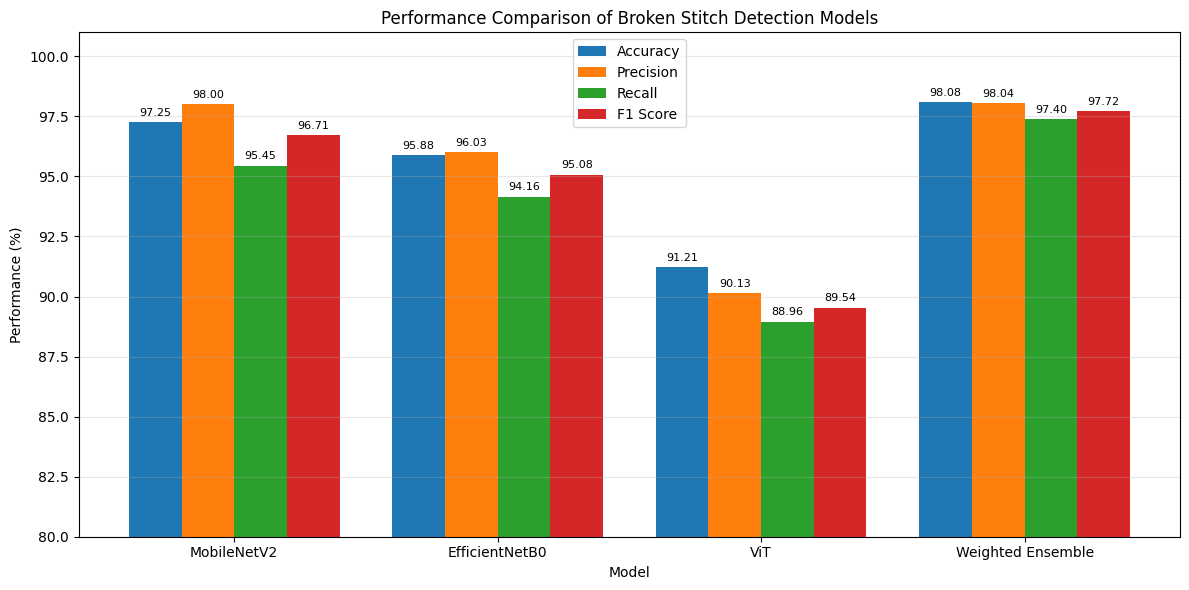

In [40]:
fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - 1.5 * width,
    accuracy,
    width,
    label="Accuracy"
)

bars2 = ax.bar(
    x - 0.5 * width,
    precision,
    width,
    label="Precision"
)

bars3 = ax.bar(
    x + 0.5 * width,
    recall,
    width,
    label="Recall"
)

bars4 = ax.bar(
    x + 1.5 * width,
    f1_score_values,
    width,
    label="F1 Score"
)

# Display values above bars
for bars in [bars1, bars2, bars3, bars4]:

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=8
    )

ax.set_xlabel("Model")
ax.set_ylabel("Performance (%)")

ax.set_title(
    "Performance Comparison of Broken Stitch Detection Models"
)

ax.set_xticks(x)
ax.set_xticklabels(models)

ax.set_ylim(80, 101)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

## 14. Save the Final Ensemble Configuration

The optimized model weights and classification threshold are stored in a JSON configuration file.

The three neural networks remain stored as separate `.keras` files, while the configuration file defines how their outputs should be combined during deployment.

This allows the same ensemble decision rule to be reproduced later in the web application or inference pipeline.

In [41]:
import json

ensemble_config = {
    "efficientnet_weight": 0.25,
    "mobilenet_weight": 0.40,
    "vit_weight": 0.35,
    "threshold": 0.50
}

with open("ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=4)

print("Ensemble configuration saved.")

Ensemble configuration saved.


## 15. Conclusion

A heterogeneous weighted soft-voting ensemble was successfully developed for binary broken-stitch classification.

The ensemble combines:

- MobileNetV2
- EfficientNetB0
- Vision Transformer

Validation-based weight optimization selected the final weights:

- **MobileNetV2 = 0.40**
- **EfficientNetB0 = 0.25**
- **ViT = 0.35**

On the independent test dataset, the final ensemble achieved:

- **Accuracy: 98.08%**
- **Precision: 98.04%**
- **Recall: 97.40%**
- **F1-score: 97.72%**

The ensemble outperformed all three individual classifiers and therefore was selected as the final classification approach for the broken-stitch detection component of the garment defect detection system.

The next stage is to integrate this classifier with a Region of Interest (ROI) extraction pipeline so that relevant stitching regions can be extracted from full-shirt images before classification.